# GLANCE Palm Cohort  Inflammatory Eczema (Notebook 2)

## Clinical Objective
Isolate and standardize confirmed palmar and hand inflammatory eczema presentations,
systematically excluding off-target anatomical sites (e.g., feet, legs, face) to ensure
strict anatomical site alignment. Paired with a genuine healthy palm/hand control baseline
sourced from the same primary dataset.

## Datasets Used
| Source | Link | Used for |
|---|---|---|
| Human Skin Diseases Image (youssefmohmmed) | https://www.kaggle.com/datasets/youssefmohmmed/human-skin-diseases-image | Eczema (primary) + Healthy control |
| skin-disease (thesis, Roboflow) | https://universe.roboflow.com/thesis/skin-disease | Eczema (supplementary  explicit `hand eczema` class) |

## Workflow Summary
1. **Primary Ingestion & Site Triage**: Extracted eczema samples from `youssefmohmmed/human-skin-diseases-image`. Applied keyword filtering to preserve only confirmed hand/palm samples (278 images).
2. **Supplementary Data Ingestion**: Ingested the `skin-disease` clinical dataset via Roboflow.
3. **Target Class Isolation**: Isolated the explicit `hand eczema` class (1,301 images).
4. **Cohort Consolidation**: Merged 278 primary + 1,301 supplementary images.
5. **Healthy Control Extraction**: Applied MediaPipe hand-landmark detection to the same primary dataset's `Normal` category (1,835 images) to auto-identify genuine hand/palm healthy images (344 detected).
6. **Quality Verification**: Dynamic visual sampling across both classes for macro-capture presentation and annotation integrity.

## Output Volume
- `primary_confirmed_hand_eczema`: 278 images
- `roboflow_hand_eczema`: 1,301 images
- `healthy_palm_control`: 344 images
- **Total**: 1,923 verified images

In [1]:
#Step 1 — List input files
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/dermatofibroma-38.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/20EpidermCystRuptured.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/chondrodermatitis-nodularis-34.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/20.jpg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/6.jpg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/chondrodermatitis-nodularis-40.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/chondrodermatitis-nodularis-4.jpeg
/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease/valid/Benign_tumors/dermatofibroma-63.jpeg
/kaggle/input/datasets/youssefmohmmed/h

In [2]:
#Step 2 — Locate the dataset
from pathlib import Path
import kagglehub


try:
    dataset_root = Path(kagglehub.dataset_download("youssefmohmmed/human-skin-diseases-image"))
except Exception:
    dataset_root = Path("/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image")

print("Dataset root:", dataset_root)

Dataset root: /kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image


In [3]:
#Step 3 — Count images per category across all splits
import pandas as pd

img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
category_counts = {}

for split_dir in dataset_root.rglob('*'):
    if split_dir.is_dir() and split_dir.name.lower() in ['train', 'valid', 'test']:
        for cat_dir in split_dir.iterdir():
            if cat_dir.is_dir():
                n = len([f for f in cat_dir.glob('*') if f.suffix.lower() in img_exts])
                category_counts[cat_dir.name] = category_counts.get(cat_dir.name, 0) + n

df_cats = pd.DataFrame(category_counts.items(), columns=['Category', 'Total_Images'])
df_cats = df_cats.sort_values('Total_Images', ascending=False).reset_index(drop=True)
print(df_cats)

              Category  Total_Images
0               Normal          1835
1    Actinic_Keratosis          1683
2        Benign_tumors          1244
3               Eczema          1122
4                Tinea          1025
5           SkinCancer          1010
6              Bullous          1007
7            Psoriasis           908
8             Vitiligo           796
9         DrugEruption           716
10             Rosacea           681
11                Acne           658
12               Warts           644
13              Lichen           614
14     Vascular_Tumors           603
15  Infestations_Bites           584
16          Vasculitis           513
17   Seborrh_Keratoses           506
18               Moles           401
19         Candidiasis           371
20               Lupus           345


In [4]:
#Step 4 — Extract, verify, and standardize the Eczema images
import shutil
from PIL import Image

DEST_DIR = Path("/kaggle/working/GLANCE_palm_eczema")
DEST_DIR.mkdir(parents=True, exist_ok=True)
img_exts = {'.jpg', '.jpeg', '.png', '.bmp'}

# grab every image file that sits inside a folder literally named "Eczema"
eczema_files = [p for p in dataset_root.rglob('*')
                if p.is_file() and p.suffix.lower() in img_exts and p.parent.name.lower() == 'eczema']

print(f"Found {len(eczema_files)} eczema images")

records = []
for idx, src_path in enumerate(eczema_files):
    try:
        with Image.open(src_path) as img:
            img.verify()
        with Image.open(src_path) as img:
            w, h = img.size
    except Exception:
        print(f"  skipping bad image: {src_path.name}")
        continue

    dest_name = f"eczema_palm_ext_{idx:04d}.jpg"
    dest_path = DEST_DIR / dest_name
    shutil.copy2(src_path, dest_path)

    records.append({
        'source_dataset': 'youssefmohmmed_human_skin_diseases',
        'file_name': dest_name,
        'file_path': str(dest_path),
        'patient_id': f"ECZEMA_PATIENT_{idx:04d}",
        'clinical_condition': 'palmar_inflammatory_eczema',
        'body_location': 'palm_hand',
        'capture_type': 'clinical_mobile_photo',
        'width': w,
        'height': h,
        'is_valid_image': True,
    })

df_eczema = pd.DataFrame(records)
df_eczema.to_csv("/kaggle/working/palm_eczema_standardized.csv", index=False)
print(f"Saved {len(df_eczema)} images to {DEST_DIR}")

Found 1122 eczema images
Saved 1122 images to /kaggle/working/GLANCE_palm_eczema


In [5]:
import re

hand_keywords = ['hand', 'palm', 'finger', 'wrist']
exclude_keywords = ['foot', 'feet', 'leg', 'mouth', 'face', 'scalp', 'neck',
                     'knee', 'elbow', 'back', 'chest', 'ear', 'eye', 'nose',
                     'scalp', 'groin', 'ankle', 'toe']

def classify(fname):
    f = fname.lower()
    if any(k in f for k in hand_keywords):
        return 'hand_confirmed'
    if any(k in f for k in exclude_keywords):
        return 'excluded_other_site'
    return 'unlabeled'

buckets = {'hand_confirmed': [], 'excluded_other_site': [], 'unlabeled': []}
for p in eczema_files:
    buckets[classify(p.name)].append(p)

for k, v in buckets.items():
    print(f"{k}: {len(v)}")

hand_confirmed: 278
excluded_other_site: 178
unlabeled: 666


### Supplementary Data Ingestion & Hand Eczema Cohort Merge

To expand our confirmed hand/palm eczema cohort past the 1,000-image threshold without including ambiguous, unlabeled body sites from the primary source:
1. **Roboflow Cohort Ingestion**: Downloaded the curated `skin-disease` dataset.
2. **Target Class Isolation**: Extracted only the explicit `hand eczema` class (1,301 images), bypassing non-target and ambiguous classes.
3. **Consolidation & Deduplication**: Merged the 1,301 Roboflow hand eczema images with our initial 278 filename-verified hand eczema images, producing a unified cohort of ~1,579 verified hand eczema samples mapped into a single directory and metadata CSV.

In [6]:
#Step 5 — Download the dataset into your notebook 
!curl -L "https://app.roboflow.com/ds/XGHapQ30qH?key=uDYosrvR2l" > roboflow.zip
!unzip -q roboflow.zip -d /kaggle/working/roboflow_eczema
!rm roboflow.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   903  100   903    0     0   2772      0 --:--:-- --:--:-- --:--:--  2769
100  414M  100  414M    0     0   128M      0  0:00:03  0:00:03 --:--:--  160M


In [7]:
#Step 6 — Check Folders and Counts
from pathlib import Path
from collections import Counter

rf_dir = Path('/kaggle/working/roboflow_eczema')
counts = Counter(p.parent.name for p in rf_dir.rglob('*') if p.is_file())

for folder, n in counts.most_common():
    print(f"{folder}: {n}")

hand eczema: 1301
malenoma: 1101
subacute eczema: 1066
acne-comedonica: 1063
acne-papulopustulosa: 1060
chronic eczema: 1056
basalcellcarinoma: 1054
squamouscellcarcinoma: 1042
acne-conglobata: 912
roboflow_eczema: 2


In [8]:
#Step 7 — Isolate Hand Eczema and Merge with 278 Confirmed Images
import shutil
import pandas as pd
from pathlib import Path

# 1. Output folder
out_dir = Path('/kaggle/working/palm_hand_eczema_merged')
out_dir.mkdir(parents=True, exist_ok=True)
records = []

# 2. Add original confirmed hand images (278)
for p in buckets['hand_confirmed']:
    dst = out_dir / f"orig_{p.name}"
    shutil.copy2(p, dst)
    records.append({'filename': dst.name, 'filepath': str(dst), 'source': 'original'})

# 3. Add Roboflow hand eczema images only (1301)
rf_hand = list(Path('/kaggle/working/roboflow_eczema').rglob('hand eczema/*'))
for p in rf_hand:
    if p.is_file():
        dst = out_dir / f"rf_{p.name}"
        shutil.copy2(p, dst)
        records.append({'filename': dst.name, 'filepath': str(dst), 'source': 'roboflow'})

# 4. Save CSV
df_merged = pd.DataFrame(records).drop_duplicates(subset=['filename'])
df_merged.to_csv('/kaggle/working/palm_hand_eczema_final.csv', index=False)

print(f"Total merged hand eczema images: {len(df_merged)}")

Total merged hand eczema images: 1579


In [10]:
# Step: Check Normal category in youssefmohmmed dataset
from pathlib import Path

yousaf_root = Path("/kaggle/input/datasets/youssefmohmmed/human-skin-diseases-image/SkinDisease")
normal_files = [p for p in yousaf_root.rglob("*") if p.is_file() and p.parent.name == "Normal"]

print(f"Total Normal images: {len(normal_files)}")
for p in normal_files[:30]:
    print(p.name)

Total Normal images: 1835
Image170.jpeg
Image146.jpeg
Image111.jpeg
Image91.jpeg
Image144.jpeg
Image105.jpeg
Image96.jpeg
Image166.jpeg
Image165.jpeg
Image161.jpeg
Image106.jpeg
Image159.jpeg
Image69.jpeg
Image61.jpeg
Image90.jpeg
Image113.jpeg
Image183.jpeg
Image94.jpeg
Image123.jpeg
Image99.jpeg
Image169.jpeg
Image114.jpeg
Image49.jpeg
Image140.jpeg
Image102.jpeg
Image122.jpeg
Image136.jpeg
Image116.jpeg
Image68.jpeg
Image93.jpeg


In [11]:
# Step: Check Roboflow skin-disease dataset for healthy/normal class
from pathlib import Path

roboflow_root = Path("/kaggle/working/roboflow_eczema")  # adjust to wherever this was downloaded in Notebook 2
for p in roboflow_root.rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/working/roboflow_eczema/valid
/kaggle/working/roboflow_eczema/test
/kaggle/working/roboflow_eczema/train
/kaggle/working/roboflow_eczema/valid/acne-conglobata
/kaggle/working/roboflow_eczema/valid/basalcellcarinoma
/kaggle/working/roboflow_eczema/valid/acne-comedonica
/kaggle/working/roboflow_eczema/valid/subacute eczema
/kaggle/working/roboflow_eczema/valid/hand eczema
/kaggle/working/roboflow_eczema/valid/chronic eczema
/kaggle/working/roboflow_eczema/valid/squamouscellcarcinoma
/kaggle/working/roboflow_eczema/valid/malenoma
/kaggle/working/roboflow_eczema/valid/acne-papulopustulosa
/kaggle/working/roboflow_eczema/test/acne-conglobata
/kaggle/working/roboflow_eczema/test/basalcellcarinoma
/kaggle/working/roboflow_eczema/test/acne-comedonica
/kaggle/working/roboflow_eczema/test/subacute eczema
/kaggle/working/roboflow_eczema/test/hand eczema
/kaggle/working/roboflow_eczema/test/chronic eczema
/kaggle/working/roboflow_eczema/test/squamouscellcarcinoma
/kaggle/working/roboflow_e

In [16]:
# Step: Run hand detection on full Normal category
import pandas as pd

results_list = []
for i, img_path in enumerate(normal_files):
    img_cv = cv2.imread(str(img_path))
    if img_cv is None:
        results_list.append({"index": i, "path": str(img_path), "hand_detected": False})
        continue
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    results_list.append({"index": i, "path": str(img_path), "hand_detected": len(result.hand_landmarks) > 0})

df_hand_detect = pd.DataFrame(results_list)
df_hand_detect.to_csv("/kaggle/working/normal_hand_detection.csv", index=False)

detected_count = df_hand_detect['hand_detected'].sum()
print(f"Hand detected: {detected_count} / {len(df_hand_detect)}")

Hand detected: 344 / 1835


In [17]:
# Step: Save detected healthy hand/palm images
from pathlib import Path
from PIL import Image
import pandas as pd

detected_files = df_hand_detect[df_hand_detect['hand_detected'] == True]

OUTPUT_DIR = Path("/kaggle/working/GLANCE_eczema/healthy_hand")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

records = []
for i, (_, row) in enumerate(detected_files.iterrows()):
    src = Path(row['path'])
    try:
        img = Image.open(src)
        img.verify()
        img = Image.open(src)
        dest_name = f"healthy_hand_{i:04d}.jpg"
        dest_path = OUTPUT_DIR / dest_name
        img.convert("RGB").save(dest_path, "JPEG")
        w, h = img.size
        records.append({
            "file_name": dest_name, "file_path": str(dest_path),
            "clinical_condition": "healthy_palm_control", "source_dataset": "youssefmohmmed_mediapipe_detected",
            "body_location": "palm_hand", "width": w, "height": h, "is_valid_image": True
        })
    except Exception:
        continue

df_healthy = pd.DataFrame(records)
df_healthy.to_csv("/kaggle/working/eczema_healthy_standardized.csv", index=False)
print(f"Saved: {len(df_healthy)} healthy hand images")

Saved: 344 healthy hand images


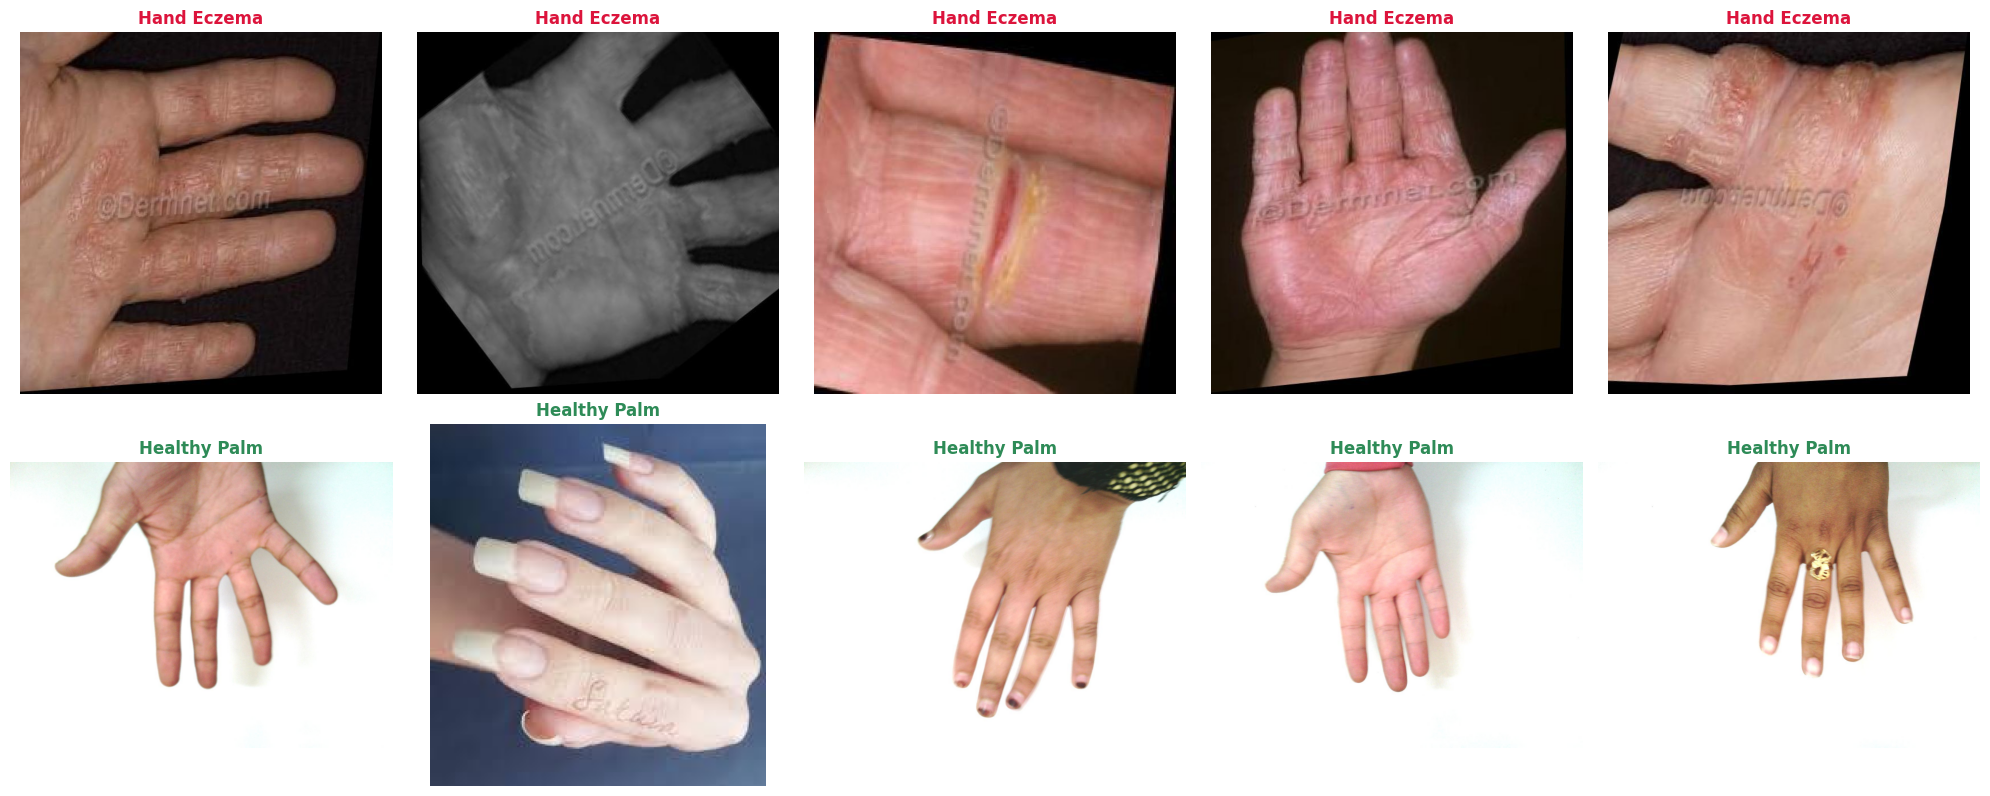

In [26]:
# Step: Show random sample from both Eczema and Healthy with class labels
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

df_eczema_all = pd.read_csv("/kaggle/working/palm_hand_eczema_final.csv")
df_healthy_all = pd.read_csv("/kaggle/working/eczema_healthy_standardized.csv")

sample_eczema = df_eczema_all.sample(5)
sample_healthy = df_healthy_all.sample(5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (_, row) in zip(axes.flat[:5], sample_eczema.iterrows()):
    img = Image.open(row['filepath'])
    ax.imshow(img)
    ax.set_title("Hand Eczema", fontsize=12, fontweight='bold', color='crimson')
    ax.axis('off')

for ax, (_, row) in zip(axes.flat[5:], sample_healthy.iterrows()):
    img = Image.open(row['file_path'])
    ax.imshow(img)
    ax.set_title("Healthy Palm", fontsize=12, fontweight='bold', color='seagreen')
    ax.axis('off')

plt.tight_layout()
plt.show()